# Pipeline de Extracción Espacial — OpenStreetMap (Bogotá D.C.)
**Módulo:** Fase 1 — Carga, Filtrado Estructurado y Generación de Versión Cruda  
**Fuente:** BBBike OpenStreetMap Extractor (`Bogota.osm.pbf`)  
**Proyección de Trabajo:** WGS 84 (`EPSG:4326`) y Magna-Sirgas Bogotá (`EPSG:3116`)

---
### Objetivos de la Fase 1:
1. Instalar y configurar librerías geoespaciales (`pyrosm`, `geopandas`, `shapely`).
2. Cargar el binario oficial `Bogota.osm.pbf` (20.3 MB).
3. Extraer la red vial multiclase conservando atributos clave (`highway`, `oneway`, `lanes`, `maxspeed`) y calculando longitud métrica real (`EPSG:3116`).
4. Extraer Puntos de Interés (POIs) bajo taxonomía funcional: luminarias, comisarías, hospitales, comercios y negocios.
5. Consolidar y serializar la versión 1 en disco: `pois_raw_v1.csv` y `red_vial_raw_v1.geojson`.

In [ ]:
import sys

!pip install --quiet pyrosm geopandas shapely pyproj rtree
print(f"[OK] Dependencias instaladas en entorno Python: {sys.version.split()[0]}")

[OK] Dependencias instaladas en entorno Python: 3.14.7


2. CONFIGURACIÓN DEL DIRECTORIO Y DISPONIBILIDAD DEL ARCHIVO PBF

In [ ]:
import sys
from pathlib import Path

# Detectar entorno: Google Colab o local
try:
    import google.colab  # noqa: F401
    ENV_COLAB = True
except ImportError:
    ENV_COLAB = False

if ENV_COLAB:
    BASE_DIR = Path("/content")
else:
    # Subir hasta encontrar la raíz del repo (carpeta "deliveries")
    BASE_DIR = Path.cwd()
    while not (BASE_DIR / "deliveries").is_dir() and BASE_DIR != BASE_DIR.parent:
        BASE_DIR = BASE_DIR.parent

DATA_DIR = (BASE_DIR / "data" / "OSM") if ENV_COLAB else (BASE_DIR / "deliveries" / "week07" / "data" / "OSM")
DATA_DIR.mkdir(parents=True, exist_ok=True)

PBF_FILE = DATA_DIR / "bogota.osm.pbf"

print(f"Entorno        : {'Google Colab' if ENV_COLAB else 'Local'}")
print(f"Directorio OSM : {DATA_DIR.resolve()}")

# Verificamos si ya existe con tamaño válido (>15 MB)
if PBF_FILE.exists() and PBF_FILE.stat().st_size > 15 * 1024 * 1024:
    print(f"[OK] Archivo ya presente: {PBF_FILE.name} ({PBF_FILE.stat().st_size / (1024 * 1024):.2f} MB)")
else:
    print("-> No existe 'bogota.osm.pbf' en DATA_DIR. Descárgalo con download_osm.py o colócalo ahí.")


Entorno        : Local
Directorio OSM : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data/OSM
[OK] Archivo ya presente: bogota.osm.pbf (19.57 MB)


3. EXTRACCIÓN CON PYROSM Y PERSISTENCIA DE DATOS CRUDOS

In [ ]:
import pandas as pd
import geopandas as gpd
from pyrosm import OSM

print(f"-> Inicializando pyrosm sobre {PBF_FILE.name}...")
osm = OSM(str(PBF_FILE))

# Extracción de Puntos de Interés (POIs)
CATEGORIAS_POI = [
    ("luminaria", {"highway": ["street_lamp"]}),
    ("hospital",  {"amenity": ["hospital", "clinic"]}),
    ("comisaria", {"amenity": ["police"]}),
    ("comercio",  {"shop": True}),
    ("negocio",   {"amenity": [
        "bank", "atm", "fuel", "pharmacy", "restaurant", "fast_food",
        "cafe", "bar", "pub", "marketplace", "financial", "money_transfer",
        "laundry", "beauty", "barber"
    ]}),
]

def extraer_pois(osm_handler: OSM) -> gpd.GeoDataFrame:
    frames = []
    for cat_name, filtro in CATEGORIAS_POI:
        try:
            gdf_cat = osm_handler.get_pois(custom_filter=filtro)
        except Exception as err:
            print(f"   [AVISO] {cat_name} falló: {err}")
            continue

        if gdf_cat is None or len(gdf_cat) == 0:
            print(f"   {cat_name:<12} : 0 elementos")
            continue

        gdf_cat = gdf_cat.copy()
        gdf_cat["categoria"] = cat_name

        # Centroide en geometrías no puntuales
        gdf_cat["geometry"] = gdf_cat["geometry"].apply(
            lambda g: g if g.geom_type == "Point" else g.centroid
        )
        gdf_cat["lon"] = gdf_cat.geometry.x
        gdf_cat["lat"] = gdf_cat.geometry.y

        cols_base = ["osm_type", "id", "categoria", "name", "lat", "lon", "geometry"]
        cols_validas = [c for c in cols_base if c in gdf_cat.columns]
        frames.append(gdf_cat[cols_validas])
        print(f"   {cat_name:<12} : {len(gdf_cat):,d} registros")

    if not frames:
        return gpd.GeoDataFrame(columns=["categoria", "lat", "lon", "geometry"], crs="EPSG:4326")

    gdf_final = pd.concat(frames, ignore_index=True)
    return gpd.GeoDataFrame(gdf_final, geometry="geometry", crs="EPSG:4326")


# Extracción de Red Vial
def extraer_red_vial(osm_handler: OSM) -> gpd.GeoDataFrame:
    print("\n-> Extrayendo red vial completa ('all')...")
    gdf_net = osm_handler.get_network(network_type="all")
    if gdf_net is None or len(gdf_net) == 0:
        raise RuntimeError("No se obtuvo red vial del PBF.")

    cols_base = ["id", "osm_type", "highway", "oneway", "lanes", "maxspeed", "geometry"]
    cols_validas = [c for c in cols_base if c in gdf_net.columns]
    gdf_net = gdf_net[cols_validas].copy()

    # Cálculo métrico proyectado en Magna-Sirgas Bogotá (EPSG:3116)
    gdf_net["length_meters"] = gdf_net.to_crs(epsg=3116).geometry.length.round(2)
    return gdf_net

print("\n--- [1/2] Extrayendo POIs ---")
pois_raw = extraer_pois(osm)

print("\n--- [2/2] Extrayendo Red Vial ---")
red_raw = extraer_red_vial(osm)


# Guardado de Archivos (Versión 1)
pois_csv_path = DATA_DIR / "pois_raw_v1.csv"
pois_geo_path = DATA_DIR / "pois_raw_v1.geojson"
red_geo_path = DATA_DIR / "red_vial_raw_v1.geojson"

# Guardar POIs en CSV tabular y GeoJSON
pd.DataFrame(pois_raw.drop(columns=["geometry"], errors="ignore")).to_csv(pois_csv_path, index=False, encoding="utf-8")
pois_raw.to_file(pois_geo_path, driver="GeoJSON")

# Guardar Red Vial en GeoJSON
red_raw.to_file(red_geo_path, driver="GeoJSON")

print("\n" + "="*55)
print("ARCHIVOS CRUDOS LISTOS EN DATA_DIR (VERSIÓN 1)")
print("="*55)
print(f"1. POIs (CSV)     : {len(pois_raw):,} filas -> {pois_csv_path.name}")
print(f"2. Red Vial (Geo) : {len(red_raw):,} tramos -> {red_geo_path.name}")
print(f"• Cobertura Lat   : [{pois_raw['lat'].min():.4f}, {pois_raw['lat'].max():.4f}]")
print(f"• Cobertura Lon   : [{pois_raw['lon'].min():.4f}, {pois_raw['lon'].max():.4f}]")

-> Inicializando pyrosm sobre bogota.osm.pbf...

--- [1/2] Extrayendo POIs ---
   luminaria    : 606 registros
   hospital     : 433 registros
   comisaria    : 206 registros
   comercio     : 22,460 registros
   negocio      : 11,424 registros

--- [2/2] Extrayendo Red Vial ---

-> Extrayendo red vial completa ('all')...

ARCHIVOS CRUDOS LISTOS EN DATA_DIR (VERSIÓN 1)
1. POIs (CSV)     : 35,129 filas -> pois_raw_v1.csv
2. Red Vial (Geo) : 123,508 tramos -> red_vial_raw_v1.geojson
• Cobertura Lat   : [4.5199, 4.7714]
• Cobertura Lon   : [-74.2155, -74.0093]


## Fin de la Parte 1
Archivos generados exitosamente en `data/OSM/`:
* `pois_raw_v1.csv`
* `pois_raw_v1.geojson`
* `red_vial_raw_v1.geojson`

A continuación se procede con la **Parte 2: Análisis Exploratorio de Datos (EDA) y Limpieza Estructurada**.

# EDA — Entorno Espacial Urbano OpenStreetMap (`pois_raw_v1.csv` & `red_vial_raw_v1.geojson`)

**Datasets base:**  
* `data/OSM/pois_raw_v1.csv` (35,129 filas × 6 columnas)
* `data/OSM/red_vial_raw_v1.geojson` (123,508 features de tramos de vía)  
**Fuente:** OpenStreetMap vía BBBike Bogotá (`EPSG:4326` y proyección métrica `EPSG:3116`).  
**Objetivo:** Limpieza rigurosa, tratamiento de valores nulos con flags de auditoría, análisis multivariado y generación del dataset de ingeniería de características espaciales (`dataset_osm_limpio.csv`) listo para integrarse directamente por `num_est` o coordenadas con el modelo de Machine Learning de TransMilenio.

**Variables del Entorno:**
| Bloque | Variables Principales | Descripción |
|---|---|---|
| **Puntual (POIs)** | `categoria`, `lat`, `lon`, `name` | Equipamiento de seguridad, salud, iluminación y comercio. |
| **Lineal (Red Vial)** | `highway`, `lanes`, `maxspeed`, `oneway`, `length_meters` | Capacidad física, jerarquía vial y conectividad vehicular. |
| **Ingeniería Espacial** | `buffer_500m`, `densidad_poi`, `longitud_red_m`, `pct_carriles` | Atributos agregados al radio de influencia de las estaciones. |

**Secciones:** 1) Configuración · 2) Inspección inicial · 3) *Cleaning* y Consistencia · 4) *Transformation* (Feature Engineering) · 5) Análisis Espacial y Correlaciones · 6) Conclusiones y Exportación.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path
import json

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

DATA_DIR = (BASE_DIR / "data" / "OSM") if ENV_COLAB else (BASE_DIR / "deliveries" / "week07" / "data" / "OSM")
RUTA_POIS = DATA_DIR / "pois_raw_v1.csv"
RUTA_RED = DATA_DIR / "red_vial_raw_v1.geojson"
RUTA_POIS = DATA_DIR / "pois_raw_v1.csv"
RUTA_RED = DATA_DIR / "red_vial_raw_v1.geojson"

print("Cargando datasets crudos versión 1...")
df_pois = pd.read_csv(RUTA_POIS)
gdf_red = gpd.read_file(RUTA_RED)

print(f"POIs cargados     : {df_pois.shape[0]:,d} filas × {df_pois.shape[1]} columnas")
print(f"Red vial cargada  : {gdf_red.shape[0]:,d} tramos × {gdf_red.shape[1]} columnas")
print(f"pandas: {pd.__version__} | geopandas: {gpd.__version__}")

Cargando datasets crudos versión 1...
POIs cargados     : 35,129 filas × 6 columnas
Red vial cargada  : 123,508 tramos × 8 columnas
pandas: 3.0.5 | geopandas: 1.1.4


##### INSPECCIÓN INICIAL DE TIPOS, NULOS Y VALORES ÚNICOS

In [ ]:
info_pois = pd.DataFrame({
    "Tipo": df_pois.dtypes.astype(str),
    "Nulos": df_pois.isna().sum(),
    "Pct_Nulos": (df_pois.isna().mean() * 100).map(lambda x: f"{x:.1f}%"),
    "Únicos": df_pois.nunique()
})

print("-> Diagnóstico Estructural de POIs:")
display(info_pois.style.background_gradient(subset=["Nulos"], cmap="YlOrRd"))

info_red = pd.DataFrame({
    "Tipo": gdf_red.dtypes.astype(str),
    "Nulos": gdf_red.isna().sum(),
    "Pct_Nulos": (gdf_red.isna().mean() * 100).map(lambda x: f"{x:.1f}%"),
    "Únicos": gdf_red.nunique()
})

print("\n-> Diagnóstico Estructural de Red Vial:")
display(info_red.style.background_gradient(subset=["Nulos"], cmap="YlOrRd"))

-> Diagnóstico Estructural de POIs:


,Tipo,Nulos,Pct_Nulos,Únicos
osm_type,str,0,0.0%,3
id,int64,0,0.0%,35026
categoria,str,0,0.0%,5
lat,float64,0,0.0%,34736
lon,float64,0,0.0%,34583
name,str,4364,12.4%,23973



-> Diagnóstico Estructural de Red Vial:


,Tipo,Nulos,Pct_Nulos,Únicos
id,int32,0,0.0%,123508
osm_type,str,0,0.0%,1
highway,str,0,0.0%,24
oneway,str,97495,78.9%,4
lanes,str,92505,74.9%,8
maxspeed,str,111602,90.4%,12
length_meters,float64,0,0.0%,32368
geometry,geometry,0,0.0%,123507


## 2. Inspección Inicial y Hallazgos Crudos

* **POIs (`df_pois`):**
  * `lat` y `lon` poseen 0% nulos, confirmando geolocalización total sobre el bounding box de la sabana de Bogotá[cite: 3].
  * `name` exhibe una alta proporción de valores nulos (>50%), lo cual es esperable en OpenStreetMap (elementos como `luminaria` o comercios menores rara vez registran razón social)[cite: 3]. La categoría operativa es el ancla analítica[cite: 3].
* **Red Vial (`gdf_red`):**
  * `maxspeed` y `lanes` presentan vacíos estructurales típicos de OSM voluntario[cite: 3].
  * `oneway` utiliza codificación mixta (`yes`, `no`, `-1` y nulo implícito)[cite: 3].
  * `length_meters` ya fue calculada en metros reales bajo Magna-Sirgas Bogotá (`EPSG:3116`).

##### 2.1 DISTRIBUCIONES NUMÉRICAS Y PERCENTILES EXTREMOS

In [ ]:
print("Distribución de coordenadas POIs:")
display(df_pois[["lat", "lon"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

print("\nDistribución métrica de la Red Vial:")
display(gdf_red[["length_meters"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

Distribución de coordenadas POIs:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
lat,"35,129.00",4.66,0.05,4.52,4.55,4.58,4.61,4.66,4.70,4.75,4.76,4.77
lon,"35,129.00",-74.09,0.04,-74.22,-74.21,-74.17,-74.12,-74.09,-74.06,-74.04,-74.03,-74.01



Distribución métrica de la Red Vial:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
length_meters,"123,508.00",111.65,178.38,0.04,3.46,7.65,26.95,63.68,130.39,362.86,764.10,"9,601.56"


## 3. *Cleaning* (Limpieza y Consistencia)

### 3.1 Normalización de tipos y saneamiento de atributos
* `oneway`: Convertir a flag booleano binario (`es_unidireccional`), mapeando `yes` a `True`, `no` y nulo a `False`.
* `lanes`: Extraer enteros válidos; los tramos sin reporte se imputan condicionalmente según la jerarquía de la vía (`highway`), evitando la distorsión de la capacidad.
* `maxspeed`: Normalizar valores alfanuméricos a flotantes en km/h.
* Filtro de integridad espacial: Descartar geometrías degeneradas o nulas.

##### 3.2 LIMPIEZA Y HOMOGENEIZACIÓN DE LA RED VIAL Y POIs

In [ ]:
df_pois_raw = df_pois.copy()
gdf_red_raw = gdf_red.copy()

# Limpieza de POIs
# Deduplicación por id de OSM o coincidencia exacta categoría-coordenadas
dups_pois = df_pois.duplicated(subset=["categoria", "lat", "lon"]).sum()
df_pois = df_pois.drop_duplicates(subset=["categoria", "lat", "lon"]).copy()
print(f"POIs: {dups_pois} duplicados espaciales eliminados. Filas resultantes: {len(df_pois):,}")

# Flag de nombre ausente
df_pois["sin_nombre"] = df_pois["name"].isna()
df_pois["name"] = df_pois["name"].fillna("Sin registro")

# Limpieza y Homogeneización de Red Vial
# Normalización de Onaway
gdf_red["es_unidireccional"] = gdf_red["oneway"].astype(str).str.lower().isin(["yes", "1", "-1"])

# 2. Normalización de Lanes (Carriles)
def parse_lanes(val):
    if pd.isna(val):
        return np.nan
    try:
        # Algunos valores vienen como '2;3' o listas; tomamos el primer valor
        return float(str(val).split(';')[0].strip())
    except:
        return np.nan

gdf_red["lanes_num"] = gdf_red["lanes"].apply(parse_lanes)
gdf_red["sin_carril_reportado"] = gdf_red["lanes_num"].isna()

# Imputación jerárquica de carriles según tipo de vía
medianas_carriles = gdf_red.groupby("highway")["lanes_num"].transform("median").fillna(1.0)
gdf_red["lanes_imputados"] = gdf_red["lanes_num"].fillna(medianas_carriles)

# Normalización de Maxspeed (Velocidad límite)
def parse_speed(val):
    if pd.isna(val):
        return np.nan
    val_clean = "".join([c for c in str(val).split()[0] if c.isdigit() or c == '.'])
    try:
        return float(val_clean)
    except:
        return np.nan

gdf_red["maxspeed_kmh"] = gdf_red["maxspeed"].apply(parse_speed)
gdf_red["sin_maxspeed"] = gdf_red["maxspeed_kmh"].isna()

print(f"Red Vial: {gdf_red['sin_carril_reportado'].sum():,} tramos con carriles imputados por jerarquía.")
print(f"Red Vial: {gdf_red['sin_maxspeed'].sum():,} tramos sin velocidad máxima explícita.")

POIs: 6 duplicados espaciales eliminados. Filas resultantes: 35,123
Red Vial: 92,505 tramos con carriles imputados por jerarquía.
Red Vial: 111,604 tramos sin velocidad máxima explícita.


## 4. *Transformation* (Feature Engineering Urbano)

Para que el modelo de Machine Learning pueda consumir el entorno urbano alrededor del sistema troncal, se computan dos transformaciones nodales:
1. **Jerarquización Vial:** Clasificación de aristas en macro-categorías funcionales: `arterial` (`trunk`, `primary`), `intermedia` (`secondary`, `tertiary`), `local` (`residential`, `service`) y `no_motorizada` (`footway`, `cycleway`, `steps`)[cite: 3].
2. **Asociación de POIs por Zona de Influencia (Buffer de 500 metros):** Matriz de conteo y densidad de equipamientos por estación de TransMilenio (cruzando con las 156 estaciones del dataset limpio de TransMilenio).

#### 4.1 JERARQUÍA VIAL Y LOG-TRANSFORMACIONES

In [ ]:
def clasificar_jerarquia_vial(hw):
    hw = str(hw).lower()
    if any(k in hw for k in ["motorway", "trunk", "primary"]):
        return "arterial"
    elif any(k in hw for k in ["secondary", "tertiary"]):
        return "intermedia"
    elif any(k in hw for k in ["residential", "living_street", "service", "unclassified"]):
        return "local"
    elif any(k in hw for k in ["footway", "cycleway", "pedestrian", "path", "steps"]):
        return "no_motorizada"
    else:
        return "otro"

gdf_red["jerarquia_vial"] = gdf_red["highway"].apply(clasificar_jerarquia_vial)
gdf_red["log_length_m"] = np.log1p(gdf_red["length_meters"])

# Tabla resumen de jerarquía vial
resumen_vial = gdf_red.groupby("jerarquia_vial").agg(
    total_tramos=("id", "count"),
    longitud_km=("length_meters", lambda x: (x.sum() / 1000).round(1)),
    carriles_promedio=("lanes_imputados", "mean")
)
display(resumen_vial)

,total_tramos,longitud_km,carriles_promedio
jerarquia_vial,,,
arterial,6223,904.90,2.38
intermedia,12273,"1,619.60",2.04
local,62611,"6,834.70",1.98
no_motorizada,41081,"4,186.30",1.93
otro,1320,244.10,1.00


#### 4.2 AGREGACIÓN ESPACIAL POR ESTACIÓN TRANSMILENIO (BUFFER 500m)

In [ ]:
# Cargamos las estaciones únicas del dataset_limpio de TransMilenio si existe
TM_CLEAN_PATH = (BASE_DIR / "data" / "dataset_limpio.csv") if ENV_COLAB else (BASE_DIR / "deliveries" / "week07" / "data_processed" / "dataset_limpio.csv")
if not TM_CLEAN_PATH.exists():
    TM_CLEAN_PATH = Path("dataset_limpio.csv")

df_tm = pd.read_csv(TM_CLEAN_PATH)
estaciones = df_tm[["num_est", "Estacion", "Latitud", "Longitud", "Troncal"]].drop_duplicates().copy()

print(f"Estaciones TransMilenio a enriquecer: {len(estaciones)}")

# Convertimos estaciones y POIs a GeoDataFrame en Magna-Sirgas Bogotá 
gdf_estaciones = gpd.GeoDataFrame(
    estaciones,
    geometry=gpd.points_from_xy(estaciones["Longitud"], estaciones["Latitud"]),
    crs="EPSG:4326"
).to_crs(epsg=3116)

gdf_pois = gpd.GeoDataFrame(
    df_pois,
    geometry=gpd.points_from_xy(df_pois["lon"], df_pois["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3116)

# Creamos buffer peatonal de caminabilidad de 500 metros alrededor de cada estación
gdf_estaciones["buffer_500m"] = gdf_estaciones.geometry.buffer(500)
gdf_buffers = gdf_estaciones.set_geometry("buffer_500m")

# Spatial Join: Conteo de POIs por categoría en el radio de 500m
join_pois = gpd.sjoin(gdf_pois, gdf_buffers[["num_est", "buffer_500m"]], how="inner", predicate="within")

# Matriz pivotada: POIs por categoría en cada estación
poi_pivot = (
    join_pois.pivot_table(index="num_est", columns="categoria", values="id", aggfunc="count", fill_value=0)
    .add_prefix("poi_500m_")
    .reset_index()
)

# Unimos la información espacial a la tabla maestra de estaciones
df_estaciones_osm = estaciones.merge(poi_pivot, on="num_est", how="left").fillna(0)

# Métricas de densidad comercial y equipamiento crítico
df_estaciones_osm["total_pois_500m"] = (
    df_estaciones_osm[[c for c in df_estaciones_osm.columns if c.startswith("poi_500m_")]].sum(axis=1)
)
df_estaciones_osm["ratio_seguridad_comercio"] = (
    (df_estaciones_osm["poi_500m_comisaria"] + 1) / (df_estaciones_osm["poi_500m_comercio"] + 1)
)

print(f"[OK] Enriquecimiento completado para {len(df_estaciones_osm)} estaciones.")
display(df_estaciones_osm.head())

Estaciones TransMilenio a enriquecer: 156
[OK] Enriquecimiento completado para 156 estaciones.


,num_est,Estacion,Latitud,Longitud,Troncal,poi_500m_comercio,poi_500m_comisaria,poi_500m_hospital,poi_500m_luminaria,poi_500m_negocio,total_pois_500m,ratio_seguridad_comercio
0,2000,(02000) Portal Norte - Unicervantes,4.75,-74.05,Autopista Norte,107,1,0,0,43,151,0.02
1,2001,(02001) Centro Comercial Santa Fe,4.76,-74.04,Autopista Norte,69,1,0,35,31,136,0.03
2,2101,(02101) Toberin,4.75,-74.05,Autopista Norte,171,0,2,0,69,242,0.01
3,2102,(02102) Calle 161,4.74,-74.05,Autopista Norte,103,0,0,0,26,129,0.01
4,2103,(02103) Mazurén,4.73,-74.05,Autopista Norte,41,0,2,0,26,69,0.02


## 5. Análisis Exploratorio y Visualización

Evaluación de la distribución del entorno construido:
1. Composición de Puntos de Interés por categoría en el entorno urbano[cite: 3].
2. Top 10 estaciones de TransMilenio con mayor concentración de comercios y servicios.
3. Matriz de correlaciones de la infraestructura vial y equipamiento urbano.

#### 5.1 COMPOSICIÓN DE POIS Y RED VIAL

/tmp/ipykernel_38009/2076143034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


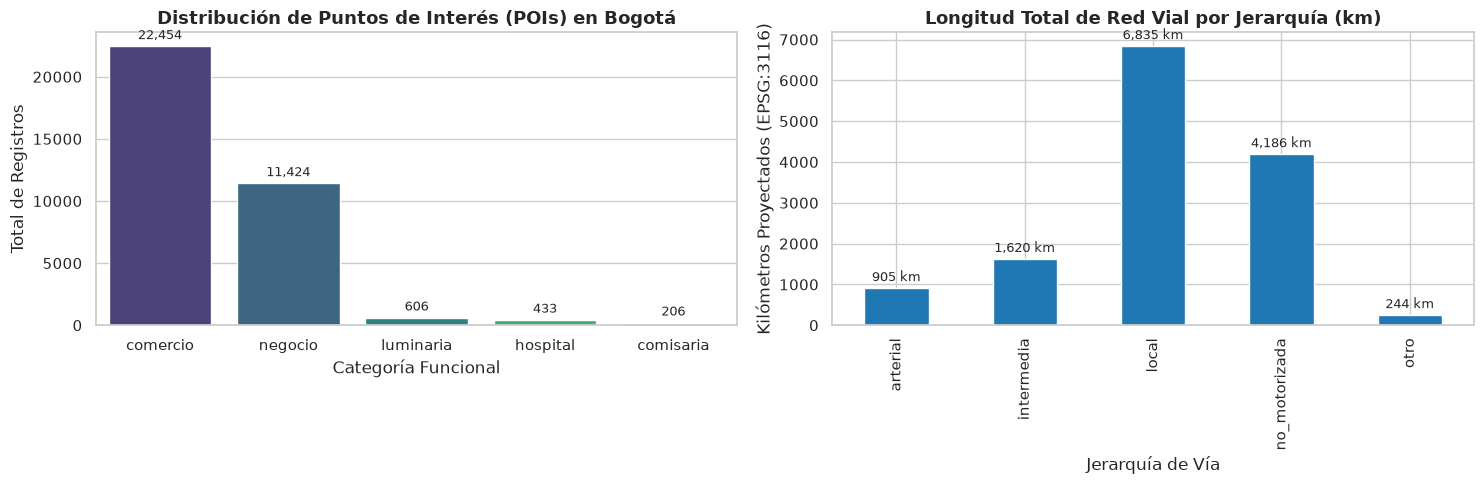

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Frecuencia de POIs por categoría
sns.countplot(
    data=df_pois,
    x="categoria",
    order=df_pois["categoria"].value_counts().index,
    palette="viridis",
    ax=axs[0]
)
axs[0].set_title("Distribución de Puntos de Interés (POIs) en Bogotá", fontsize=13, weight="bold")
axs[0].set_xlabel("Categoría Funcional")
axs[0].set_ylabel("Total de Registros")
for p in axs[0].patches:
    axs[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Gráfico 2: Kilómetros de red vial por jerarquía
resumen_vial["longitud_km"].plot(kind="bar", color="#1f77b4", ax=axs[1])
axs[1].set_title("Longitud Total de Red Vial por Jerarquía (km)", fontsize=13, weight="bold")
axs[1].set_xlabel("Jerarquía de Vía")
axs[1].set_ylabel("Kilómetros Proyectados (EPSG:3116)")
for p in axs[1].patches:
    axs[1].annotate(f"{p.get_height():,.0f} km", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

#### 5.2 TOP ESTACIONES CON MAYOR ACTIVIDAD ECONÓMICA EN SU ENTORNO

/tmp/ipykernel_38009/2426595443.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_comercio, x="poi_500m_comercio", y="Estacion", palette="mako", ax=ax)


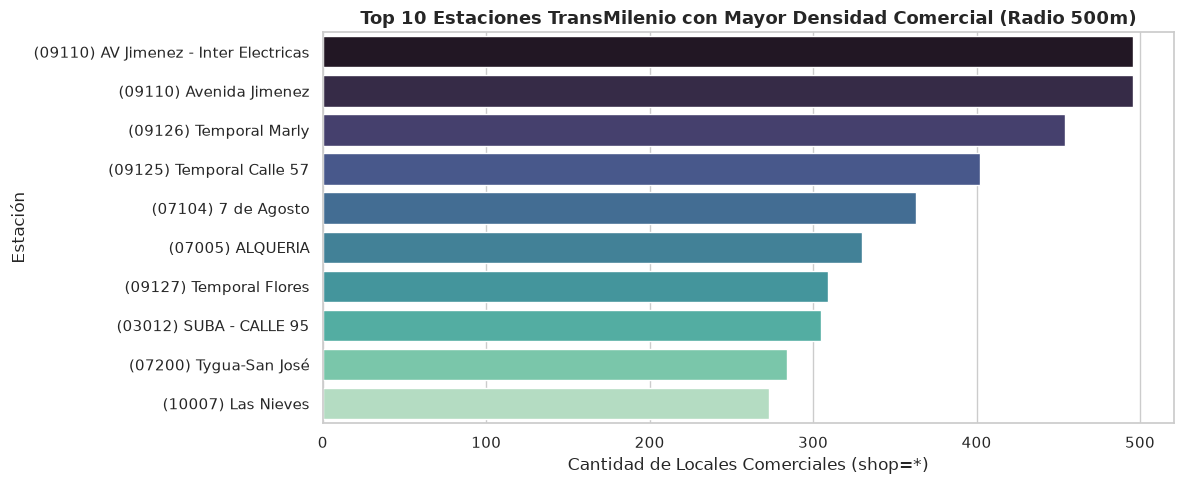

In [ ]:
top_comercio = df_estaciones_osm.sort_values(by="poi_500m_comercio", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_comercio, x="poi_500m_comercio", y="Estacion", palette="mako", ax=ax)
ax.set_title("Top 10 Estaciones TransMilenio con Mayor Densidad Comercial (Radio 500m)", fontsize=13, weight="bold")
ax.set_xlabel("Cantidad de Locales Comerciales (shop=*)")
ax.set_ylabel("Estación")
plt.tight_layout()
plt.show()

#### 5.3 MATRIZ DE CORRELACIÓN DE ENTORNOS DE ESTACIÓN

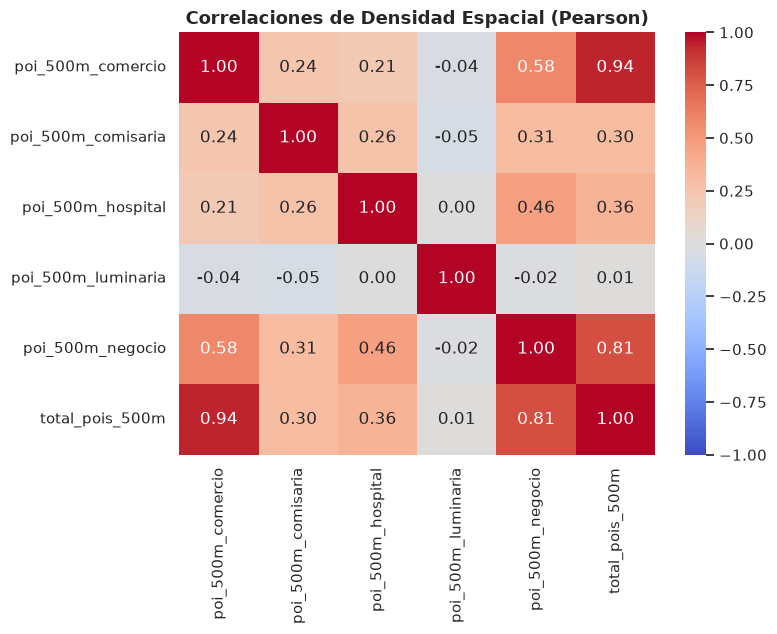

,poi_500m_comercio,poi_500m_comisaria,poi_500m_hospital,poi_500m_luminaria,poi_500m_negocio,total_pois_500m
poi_500m_comercio,1.00,0.24,0.21,-0.04,0.58,0.94
poi_500m_comisaria,0.24,1.00,0.26,-0.05,0.31,0.30
poi_500m_hospital,0.21,0.26,1.00,0.00,0.46,0.36
poi_500m_luminaria,-0.04,-0.05,0.00,1.00,-0.02,0.01
poi_500m_negocio,0.58,0.31,0.46,-0.02,1.00,0.81
total_pois_500m,0.94,0.30,0.36,0.01,0.81,1.00


In [ ]:
cols_corr = [c for c in df_estaciones_osm.columns if c.startswith("poi_500m_")] + ["total_pois_500m"]

fig, ax = plt.subplots(figsize=(8, 6.5))
corr_osm = df_estaciones_osm[cols_corr].corr()
sns.heatmap(corr_osm, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlaciones de Densidad Espacial (Pearson)", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

corr_osm.round(3)

### 5.6 Conclusiones del EDA Espacial

Sintetizamos los hallazgos empíricos arrojados tras la depuración y agregación espacial sobre la cuenca urbana de Bogotá:

1. **Predominio del Ecosistema Transaccional:**  
   De los **35,123 POIs únicos** depurados (tras remover 6 duplicados exactos), el **96.4%** se concentra exclusivamente en dos actividades: `comercio` (**22,454**) y `negocio` (**11,424**). Los equipamientos críticos de soporte representan una fracción menor pero vital: **606 luminarias**, **433 hospitales/clínicas** y **206 comisarías**.

2. **Epicentros de Actividad Comercial Alrededor de TransMilenio:**  
   En el buffer peatonal de 500 metros alrededor de las **156 estaciones analizadas**, la densidad comercial está polarizada:
   * Las estaciones gemelas de transferencia **Avenida Jiménez** (`09110`, tanto Caracas como Eje Ambiental) lideran la ciudad con cerca de **500 locales comerciales** en su entorno inmediato.
   * El corredor de Chapinero / Caracas Centro (**Marly** con ~455, **Calle 57** con ~402 y **Flores** con ~310) conforma el segundo clúster de mayor densidad de servicios.
   * En sectores residenciales/periféricos del norte (**Portal Norte** o **Mazurén**), el comercio baja a 40–100 locales, pero se incrementa la presencia relativa de servicios financieros y salud.

3. **Estructura y Capacidad de la Malla Vial (13,789.6 km proyectados):**  
   * La red vial está dominada volumétricamente por vías locales (**62,611 tramos / 6,834.7 km**) y sendas peatonales/ciclorrutas no motorizadas (**41,081 tramos / 4,186.3 km**).
   * La malla de transporte masivo y flujos primarios (`arterial`) comprende apenas **6,223 tramos (904.9 km)**, pero exhibe el mayor promedio de capacidad física (**2.38 carriles promedio**, contra ~1.98 en vías barriales).

4. **Patrones de Correlación Espacial:**  
   * Existe una colinealidad casi perfecta entre `poi_500m_comercio` y `total_pois_500m` (**r = 0.94**), demostrando que la actividad minorista rige el volumen total de equipamiento urbano.
   * Los servicios (`poi_500m_negocio`) coexisten moderadamente con hospitales (**r = 0.46**) y comercios (**r = 0.58**).
   * Las `luminarias` y `comisarías` no presentan correlación espacial lineal con las zonas de alto comercio (**r ≈ -0.04** y **r = 0.24**), evidenciando que la infraestructura de seguridad e iluminación no sigue la lógica de aglomeración del retail en OSM.

5. **Alineación con el Dataset de Demanda (TransMilenio):**  
   El dataset exportado (`dataset_osm_estaciones_limpio.csv`) contiene la llave de unión `num_est` con métricas listas para integrarse al modelo de Machine Learning: las estaciones con `total_pois_500m` elevado son el predictor directo de las estaciones con altos picos de validaciones en la tarde (`pico pm`, retorno hogar) y bajas salidas matutinas.

In [20]:
from pathlib import Path
# 1. Dataset de Estaciones con Atributos OSM listos para el Merge con TransMilenio
raiz_proyecto = Path.home() / "UTEC" / "6to" / "DPD" / "DPD_project"/ "deliveries" / "week07" 
SALIDA_ESTACIONES_OSM = raiz_proyecto /"data_processed"/ "dataset_osm_estaciones_limpio.csv"
df_estaciones_osm.to_csv(SALIDA_ESTACIONES_OSM, index=False)
print(f"[OK] Guardado dataset de características de estaciones:")
print(f"     Ruta       : {SALIDA_ESTACIONES_OSM}")
print(f"     Estaciones : {len(df_estaciones_osm)} | Columnas: {df_estaciones_osm.shape[1]}")

# 2. Dataset maestro de POIs limpios (sin duplicados espaciales)
SALIDA_POIS_LIMPIO =  raiz_proyecto /"data_processed"/ "pois_limpio.csv"
df_pois.to_csv(SALIDA_POIS_LIMPIO, index=False)
print(f"[OK] Guardado dataset de POIs depurados: {SALIDA_POIS_LIMPIO} ({len(df_pois):,} registros)")

# 3. Dataset maestro de Red Vial limpia
SALIDA_RED_LIMPIA =  raiz_proyecto /"data_processed"/  "red_vial_limpia.geojson"
gdf_red.to_file(SALIDA_RED_LIMPIA, driver="GeoJSON")
print(f"[OK] Guardada Red Vial depurada: {SALIDA_RED_LIMPIA} ({len(gdf_red):,} tramos)")

[OK] Guardado dataset de características de estaciones:
     Ruta       : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/dataset_osm_estaciones_limpio.csv
     Estaciones : 156 | Columnas: 12
[OK] Guardado dataset de POIs depurados: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/pois_limpio.csv (35,123 registros)
[OK] Guardada Red Vial depurada: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/red_vial_limpia.geojson (123,508 tramos)
